# Volatility-Targeted Time-Series Momentum Strategy

This notebook presents the complete implementation and evaluation of a volatility-targeted time-series momentum strategy.

The analysis includes:

- historical price data
- momentum signal construction
- volatility estimation
- position scaling
- transaction costs
- backtest evaluation
- comparison with buy-and-hold
- sensitivity analysis 

In [140]:
import sys 
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.backtest import run_backtest
from src.data_loader import add_daily_returns, download_price_data
from src.metrics import calculate_performance_metrics
from src.signals import generate_momentum_signal
from src.volatility import (
    calculate_rolling_volatility,
    calculate_volatility_scaler,
)

pd.set_option("display.float_format", lambda value: f"{value:.4f}") 

In [141]:
print("Notebook is working")

Notebook is working


In [142]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.backtest import run_backtest
from src.data_loader import add_daily_returns, download_price_data
from src.metrics import calculate_performance_metrics
from src.signals import generate_momentum_signal
from src.volatility import (
    calculate_rolling_volatility,
    calculate_volatility_scaler,
)

pd.set_option("display.float_format", lambda value: f"{value:.4f}")

In [143]:
print("Project root:", PROJECT_ROOT)

Project root: c:\Users\benre\VTM


In [144]:
TICKER = "SPY"
START_DATE = "2000-01-01"

MOMENTUM_LOOKBACK = 252
VOLATILITY_WINDOW = 20
TARGET_VOLATILITY = 0.10
MAXIMUM_LEVERAGE = 2.0
TRANSACTION_COST_BPS = 5

## 1. Strategy Configuration

The strategy uses a 12-month momentum lookback, estimated with 252 trading days.  
Realized volatility is calculated using a 20-day rolling window.

The portfolio is scaled toward a 10% annualized volatility target, with leverage capped at 2.0.  
Transaction costs are set to 5 basis points.

In [145]:
data = download_price_data(
    ticker=TICKER,
    start_date=START_DATE,
)

data = add_daily_returns(data)

data.head()

Price,Close,High,Low,Open,Volume,Return
Ticker,SPY,SPY,SPY,SPY,SPY,
Date,,,,,,
2000-01-04,87.5689,90.2711,87.5003,89.9382,8089800,-0.0391
2000-01-05,87.7255,88.6850,86.0023,87.6864,12177900,0.0018
2000-01-06,86.3157,88.6655,86.3157,87.4906,6227200,-0.0161
2000-01-07,91.3285,91.3285,87.7647,87.9213,8066500,0.0581
2000-01-10,91.6419,92.0531,90.8782,91.6419,5741700,0.0034


In [146]:
print("Ticker:", TICKER)
print("Start date:", data.index.min())
print("End date:", data.index.max())
print("Number of observations:", len(data))

data.tail()

Ticker: SPY
Start date: 2000-01-04 00:00:00
End date: 2026-07-17 00:00:00
Number of observations: 6673


Price,Close,High,Low,Open,Volume,Return
Ticker,SPY,SPY,SPY,SPY,SPY,
Date,,,,,,
2026-07-13,749.1700,753.9100,748.0000,752.4700,44013600,-0.0077
2026-07-14,751.8300,753.3400,748.6600,750.9100,35143100,0.0036
2026-07-15,754.8100,755.5800,750.2000,754.2400,43844800,0.0040
2026-07-16,750.7200,754.5700,747.8800,752.7600,46409800,-0.0054
2026-07-17,743.2900,747.2900,740.8000,742.0800,62569200,-0.0099


## 2. Signal and Volatility Estimation

The strategy takes a long position when the historical momentum return is positive and a short position when it is negative.

The signal is shifted by one trading day to prevent look-ahead bias.

Position size is adjusted using recent realized volatility. Exposure increases when volatility is low and decreases when volatility is high, subject to the maximum leverage limit.

In [147]:
prices = data["Close"].squeeze()
returns = data["Return"].squeeze()

print("Prices shape:", prices.shape)
print("Returns shape:", returns.shape)

Prices shape: (6673,)
Returns shape: (6673,)


In [148]:
signal = generate_momentum_signal(
    prices=prices,
    lookback_days=MOMENTUM_LOOKBACK,
)

signal.dropna().head()

Date
2000-01-05   0.0000
2000-01-06   0.0000
2000-01-07   0.0000
2000-01-10   0.0000
2000-01-11   0.0000
Name: Momentum_Signal, dtype: float64

In [149]:
print(signal.value_counts(dropna=False))

Momentum_Signal
1.0000     4969
-1.0000    1451
0.0000      252
NaN           1
Name: count, dtype: int64


In [150]:
rolling_volatility = calculate_rolling_volatility(
    returns=returns,
    window=VOLATILITY_WINDOW,
)

rolling_volatility.describe()

count   6654.0000
mean       0.1626
std        0.1059
min        0.0319
25%        0.0974
50%        0.1364
75%        0.1961
max        0.9592
Name: Return, dtype: float64

In [151]:
volatility_scaler = calculate_volatility_scaler(
    volatility=rolling_volatility,
    target_volatility=TARGET_VOLATILITY,
    maximum_leverage=MAXIMUM_LEVERAGE,
)

volatility_scaler.describe()

count   6653.0000
mean       0.7987
std        0.3762
min        0.1043
25%        0.5098
50%        0.7331
75%        1.0265
max        2.0000
Name: Return, dtype: float64

## 3. Backtest

The strategy is evaluated by combining the momentum signal with volatility scaling. Daily returns are adjusted for transaction costs before computing cumulative wealth.

In [152]:
backtest_result = run_backtest(
    returns=returns,
    signal=signal,
    volatility_scaler=volatility_scaler,
    transaction_cost_bps=TRANSACTION_COST_BPS,
)

backtest_result.head()

,Asset_Return,Momentum_Signal,Volatility_Scaler,Position,Gross_Strategy_Return,Turnover,Transaction_Cost,Net_Strategy_Return,Buy_and_Hold_Wealth,Strategy_Wealth
Date,,,,,,,,,,
2001-01-04,-0.0108,-1.0000,0.2871,-0.2871,0.0031,0.2871,0.0001,0.0029,0.9892,1.0029
2001-01-05,-0.0326,-1.0000,0.3037,-0.3037,0.0099,0.0165,0.0000,0.0099,0.9569,1.0129
2001-01-08,0.0077,-1.0000,0.2905,-0.2905,-0.0022,0.0131,0.0000,-0.0023,0.9644,1.0106
2001-01-09,-0.0026,-1.0000,0.2916,-0.2916,0.0008,0.0011,0.0000,0.0008,0.9618,1.0114
2001-01-10,0.0176,-1.0000,0.2918,-0.2918,-0.0051,0.0001,0.0000,-0.0051,0.9787,1.0062


In [153]:
backtest_result.tail()

,Asset_Return,Momentum_Signal,Volatility_Scaler,Position,Gross_Strategy_Return,Turnover,Transaction_Cost,Net_Strategy_Return,Buy_and_Hold_Wealth,Strategy_Wealth
Date,,,,,,,,,,
2026-07-13,-0.0077,1.0000,0.6771,0.6771,-0.0052,0.0539,0.0000,-0.0052,8.7641,4.1509
2026-07-14,0.0036,1.0000,0.7112,0.7112,0.0025,0.0341,0.0000,0.0025,8.7952,4.1613
2026-07-15,0.0040,1.0000,0.7144,0.7144,0.0028,0.0032,0.0000,0.0028,8.8300,4.1731
2026-07-16,-0.0054,1.0000,0.7941,0.7941,-0.0043,0.0797,0.0000,-0.0043,8.7822,4.1550
2026-07-17,-0.0099,1.0000,0.7963,0.7963,-0.0079,0.0021,0.0000,-0.0079,8.6953,4.1222


## 4. Performance Evaluation

The strategy is compared with a passive buy-and-hold investment using the following metrics:

- CAGR
- Annualized Volatility
- Sharpe Ratio
- Sortino Ratio
- Maximum Drawdown
- Calmar Ratio

In [154]:
strategy_metrics = calculate_performance_metrics(
    backtest_result["Net_Strategy_Return"]
)

benchmark_metrics = calculate_performance_metrics(
    backtest_result["Asset_Return"]
)

comparison = pd.DataFrame(
    {
        "Strategy": strategy_metrics,
        "Buy and Hold": benchmark_metrics,
    }
)

comparison

,Strategy,Buy and Hold
CAGR,0.0572,0.0886
Annualized Volatility,0.1113,0.1907
Sharpe Ratio,0.5553,0.5406
Sortino Ratio,0.7237,0.6790
Maximum Drawdown,-0.3131,-0.5519
Calmar Ratio,0.1826,0.1605


In [155]:
comparison.to_csv(
    PROJECT_ROOT / "results" / "performance_metrics.csv"
)

comparison

,Strategy,Buy and Hold
CAGR,0.0572,0.0886
Annualized Volatility,0.1113,0.1907
Sharpe Ratio,0.5553,0.5406
Sortino Ratio,0.7237,0.6790
Maximum Drawdown,-0.3131,-0.5519
Calmar Ratio,0.1826,0.1605


In [156]:
print(
    "Final Strategy Wealth:",
    round(backtest_result["Strategy_Wealth"].iloc[-1], 4),
)

print(
    "Final Buy-and-Hold Wealth:",
    round(backtest_result["Buy_and_Hold_Wealth"].iloc[-1], 4),
)

Final Strategy Wealth: 4.1222
Final Buy-and-Hold Wealth: 8.6953


# 5. Strategy Performance Visualization

This section compares the cumulative performance of the volatility-targeted momentum strategy with a passive buy-and-hold investment. It also illustrates the evolution of drawdowns throughout the investment horizon.

In [ ]:
from src.visualization import plot_wealth_curves

plot_wealth_curves(
    backtest_result,
    output_path=PROJECT_ROOT / "results" / "wealth_curves.png",
)

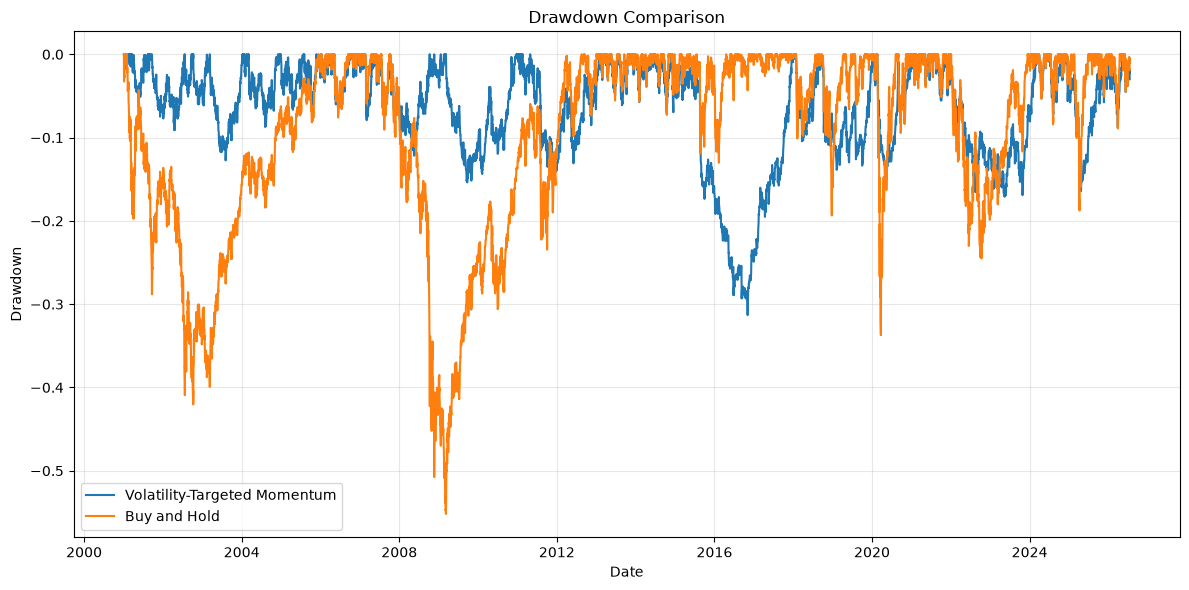

In [ ]:
from src.visualization import plot_drawdowns

plot_drawdowns(
    backtest_result,
    output_path=PROJECT_ROOT / "results" / "drawdowns.png",
)

## 6. Multi-Asset Comparison

To evaluate whether the strategy is robust across different asset classes, the same volatility-targeted momentum framework is applied to six ETFs:

- SPY: U.S. equities
- QQQ: U.S. technology equities
- GLD: Gold
- TLT: Long-term U.S. Treasury bonds
- DBC: Broad commodities
- VNQ: U.S. real estate

In [ ]:
from src.multi_asset import compare_assets

ASSETS = {
    "SPY": "SPY",
    "QQQ": "QQQ",
    "GLD": "GLD",
    "TLT": "TLT",
    "DBC": "DBC",
    "VNQ": "VNQ",
}

asset_metrics, asset_backtests = compare_assets(ASSETS)

asset_metrics.round(4)

,CAGR,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Maximum Drawdown,Calmar Ratio
SPY,0.0572,0.1113,0.5553,0.7237,-0.3131,0.1826
QQQ,0.0605,0.1100,0.5888,0.8017,-0.2685,0.2253
GLD,0.0313,0.1114,0.3322,0.4656,-0.4650,0.0672
TLT,-0.0216,0.1067,-0.1509,-0.2332,-0.5698,-0.0378
DBC,0.0122,0.1102,0.1650,0.2411,-0.3651,0.0334
VNQ,0.0111,0.1094,0.1558,0.2229,-0.3230,0.0344


In [ ]:
asset_metrics.to_csv(
    PROJECT_ROOT / "results" / "multi_asset_metrics.csv"
)

asset_metrics.round(4)

,CAGR,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Maximum Drawdown,Calmar Ratio
SPY,0.0572,0.1113,0.5553,0.7237,-0.3131,0.1826
QQQ,0.0605,0.1100,0.5888,0.8017,-0.2685,0.2253
GLD,0.0313,0.1114,0.3322,0.4656,-0.4650,0.0672
TLT,-0.0216,0.1067,-0.1509,-0.2332,-0.5698,-0.0378
DBC,0.0122,0.1102,0.1650,0.2411,-0.3651,0.0334
VNQ,0.0111,0.1094,0.1558,0.2229,-0.3230,0.0344


In [ ]:
best_sharpe_asset = asset_metrics["Sharpe Ratio"].idxmax()
best_cagr_asset = asset_metrics["CAGR"].idxmax()
lowest_drawdown_asset = asset_metrics["Maximum Drawdown"].idxmax()

print("Highest Sharpe ratio:", best_sharpe_asset)
print("Highest CAGR:", best_cagr_asset)
print("Smallest maximum drawdown:", lowest_drawdown_asset)

Highest Sharpe ratio: QQQ
Highest CAGR: QQQ
Smallest maximum drawdown: QQQ


### Interpretation

The results show that the strategy does not perform uniformly across all asset classes.

QQQ records the strongest overall risk-adjusted performance, while SPY also produces positive long-term results. GLD provides a positive but weaker contribution.

The strategy performs poorly on TLT over the selected sample, with a negative CAGR and a large maximum drawdown. DBC and VNQ also show relatively low returns despite maintaining volatility close to the target.

These differences support the construction of a diversified multi-asset portfolio rather than relying on a single market.

## 7. Multi-Asset Portfolio Construction

The individual volatility-targeted momentum strategies are combined into one diversified portfolio.

Portfolio weights are determined using inverse volatility. Assets with lower recent volatility receive larger weights, while assets with higher volatility receive smaller weights.

In [ ]:
from src.multi_asset import (
    build_multi_asset_portfolio,
    build_strategy_return_matrix,
    calculate_inverse_volatility_weights,
) 

In [ ]:
strategy_return_matrix = build_strategy_return_matrix(
    asset_backtests
)

strategy_return_matrix.head()

,SPY,QQQ,GLD,TLT,DBC,VNQ
Date,,,,,,
2007-02-09,-0.0102,-0.0097,0.0057,-0.0089,0.0023,-0.0098
2007-02-12,-0.0044,-0.0029,-0.0042,-0.0036,-0.0075,-0.0141
2007-02-13,0.0112,0.0026,0.0018,-0.0035,0.0073,0.0128
2007-02-14,0.0081,0.0127,0.0056,0.0154,-0.0056,-0.0045
2007-02-15,0.0016,0.0040,0.0004,0.0041,-0.0000,0.0046


In [ ]:
portfolio_weights = calculate_inverse_volatility_weights(
    strategy_returns=strategy_return_matrix,
    window=VOLATILITY_WINDOW,
)

portfolio_weights.tail()

,SPY,QQQ,GLD,TLT,DBC,VNQ
Date,,,,,,
2026-07-13,0.1814,0.1633,0.1862,0.1411,0.1592,0.1688
2026-07-14,0.1878,0.1732,0.1926,0.1500,0.1342,0.1622
2026-07-15,0.1895,0.1726,0.1865,0.1505,0.1350,0.1659
2026-07-16,0.2005,0.1817,0.1926,0.1402,0.1284,0.1567
2026-07-17,0.2035,0.1864,0.1868,0.1473,0.1315,0.1445


In [ ]:
portfolio_weights.sum(axis=1).tail()

Date
2026-07-13   1.0000
2026-07-14   1.0000
2026-07-15   1.0000
2026-07-16   1.0000
2026-07-17   1.0000
dtype: float64

# 8. Portfolio Construction

To evaluate the strategy in a diversified setting, the individual asset strategies are combined into a single multi-asset portfolio.

The portfolio is constructed using **inverse-volatility weighting**, where assets with lower recent volatility receive larger portfolio weights, while more volatile assets receive smaller allocations. The weights are normalized daily so that the total portfolio exposure equals one.

This approach aims to improve diversification by reducing the concentration of risk in highly volatile assets while maintaining exposure across multiple asset classes.

In [ ]:
portfolio_result = build_multi_asset_portfolio(
    strategy_returns=strategy_return_matrix,
    weights=portfolio_weights,
)

portfolio_result.tail()

,Portfolio_Return,Portfolio_Wealth
Date,,
2026-07-13,-0.0017,1.6180
2026-07-14,0.0029,1.6226
2026-07-15,0.0014,1.6248
2026-07-16,-0.0024,1.6209
2026-07-17,-0.0002,1.6206


In [ ]:
portfolio_metrics = calculate_performance_metrics(
    portfolio_result["Portfolio_Return"]
)

portfolio_metrics

CAGR                     0.0252
Annualized Volatility    0.0589
Sharpe Ratio             0.4523
Sortino Ratio            0.5971
Maximum Drawdown        -0.1628
Calmar Ratio             0.1548
dtype: float64

# 9. Portfolio-Level Volatility Targeting

Although inverse-volatility weighting improves diversification, the resulting portfolio does not necessarily achieve the desired level of risk. In this study, the initial diversified portfolio exhibited an annualized volatility of approximately **5.9%**, which is well below the target of **10%**.

To address this, a second volatility-targeting step is applied to the portfolio as a whole. The portfolio exposure is dynamically adjusted according to its recent realized volatility. Exposure increases when realized volatility is below the target and decreases when volatility rises above the target, while respecting the maximum leverage constraint.

This final step ensures that the portfolio maintains a more consistent level of risk throughout the investment period and allows a fair comparison with the single-asset strategies.

In [ ]:
from src.multi_asset import apply_portfolio_volatility_target

In [ ]:
targeted_portfolio = apply_portfolio_volatility_target(
    portfolio_returns=portfolio_result["Portfolio_Return"],
    target_volatility=TARGET_VOLATILITY,
    window=VOLATILITY_WINDOW,
    maximum_leverage=MAXIMUM_LEVERAGE,
)

targeted_portfolio.tail()

,Raw_Portfolio_Return,Portfolio_Realized_Volatility,Portfolio_Scaler,Targeted_Portfolio_Return,Targeted_Portfolio_Wealth
Date,,,,,
2026-07-13,-0.0017,0.0469,2.0000,-0.0034,2.4471
2026-07-14,0.0029,0.0400,2.0000,0.0057,2.4611
2026-07-15,0.0014,0.0416,2.0000,0.0027,2.4678
2026-07-16,-0.0024,0.0410,2.0000,-0.0048,2.4560
2026-07-17,-0.0002,0.0417,2.0000,-0.0004,2.4550


In [ ]:
targeted_portfolio_metrics = calculate_performance_metrics(
    targeted_portfolio["Targeted_Portfolio_Return"].dropna()
)

targeted_portfolio_metrics

CAGR                     0.0476
Annualized Volatility    0.1016
Sharpe Ratio             0.5086
Sortino Ratio            0.6739
Maximum Drawdown        -0.2245
Calmar Ratio             0.2120
dtype: float64

In [ ]:
portfolio_comparison = pd.DataFrame(
    {
        "Unscaled Portfolio": portfolio_metrics,
        "10% Targeted Portfolio": targeted_portfolio_metrics,
    }
)

portfolio_comparison.round(4)

,Unscaled Portfolio,10% Targeted Portfolio
CAGR,0.0252,0.0476
Annualized Volatility,0.0589,0.1016
Sharpe Ratio,0.4523,0.5086
Sortino Ratio,0.5971,0.6739
Maximum Drawdown,-0.1628,-0.2245
Calmar Ratio,0.1548,0.2120


# 10. Portfolio Allocation

This figure illustrates how the inverse-volatility weighting scheme allocates capital across the six ETFs over time.

Assets with lower estimated volatility receive larger portfolio weights, while more volatile assets receive smaller allocations. The weights evolve dynamically as market conditions change.

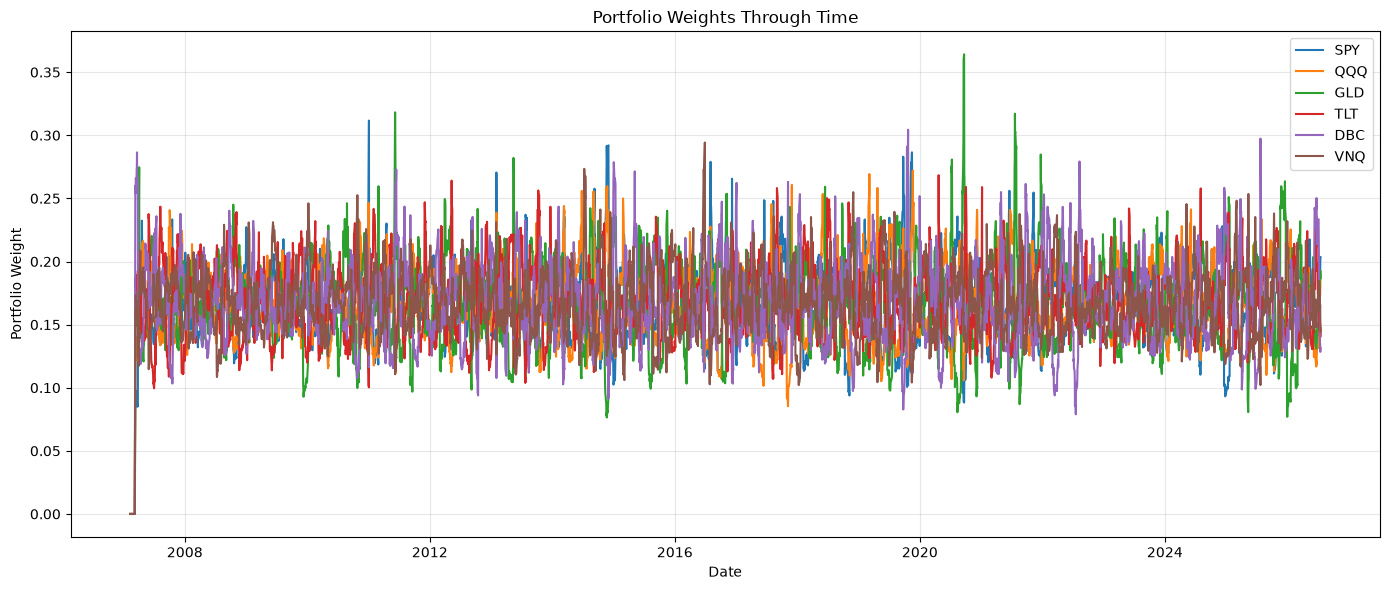

In [ ]:
plt.figure(figsize=(14, 6))

for asset in portfolio_weights.columns:
    plt.plot(
        portfolio_weights.index,
        portfolio_weights[asset],
        label=asset,
    )

plt.title("Portfolio Weights Through Time")
plt.xlabel("Date")
plt.ylabel("Portfolio Weight")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## Portfolio Leverage

The figure below shows the portfolio scaling factor used to maintain the target volatility.

When portfolio volatility decreases, exposure increases. Conversely, when realized volatility rises, the scaling factor decreases to maintain a consistent level of risk.

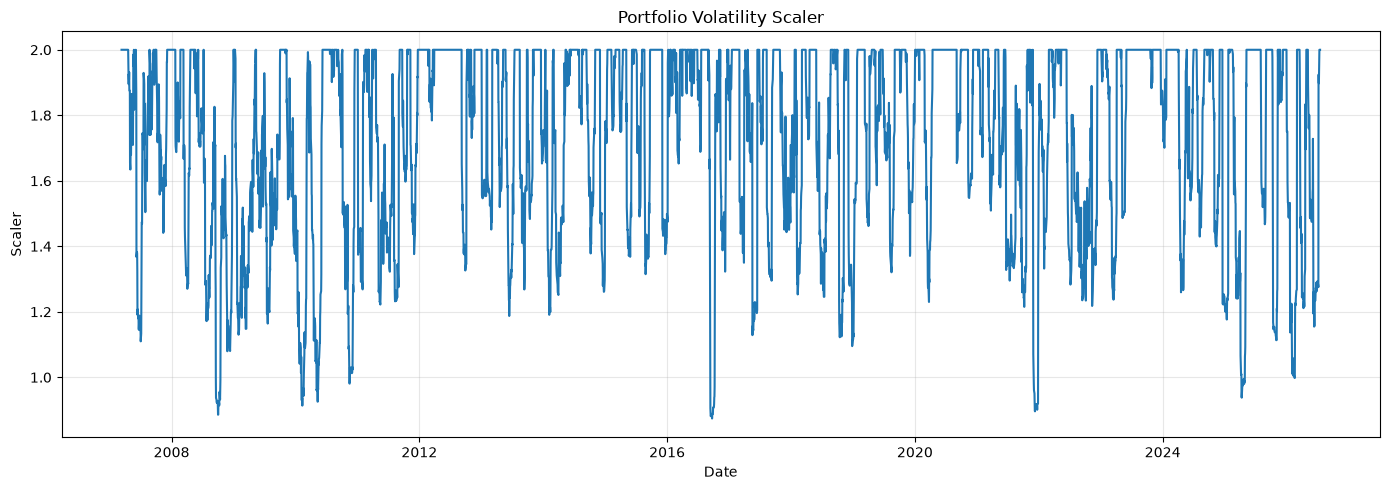

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(
    targeted_portfolio.index,
    targeted_portfolio["Portfolio_Scaler"],
)

plt.title("Portfolio Volatility Scaler")
plt.xlabel("Date")
plt.ylabel("Scaler")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Rolling Portfolio Volatility

The following figure illustrates the evolution of the portfolio's realized annualized volatility after applying volatility targeting.

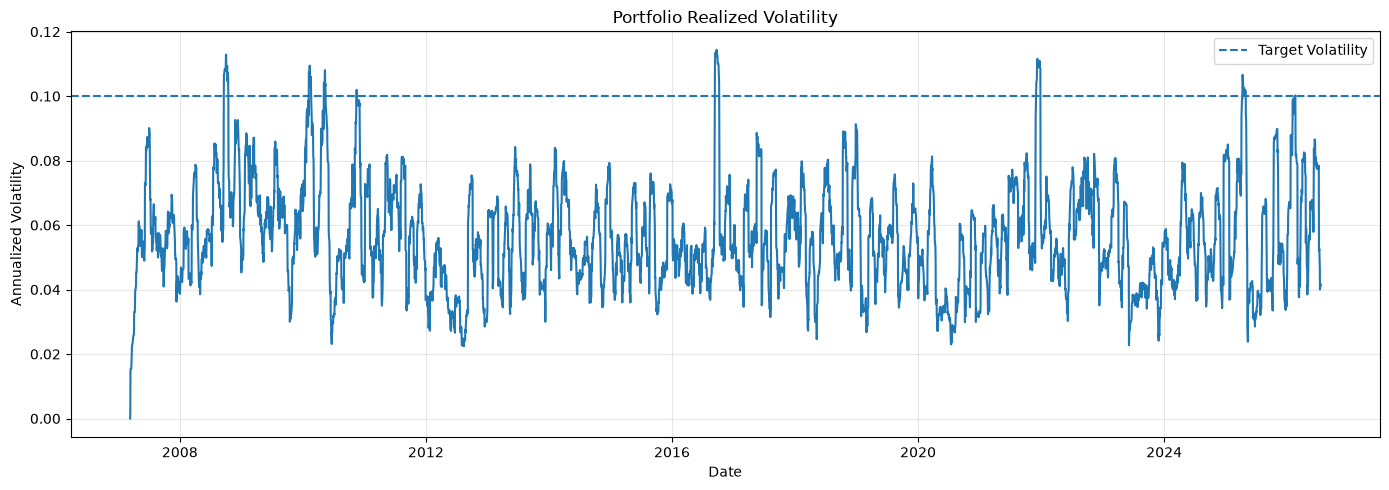

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(
    targeted_portfolio.index,
    targeted_portfolio["Portfolio_Realized_Volatility"],
)

plt.axhline(
    TARGET_VOLATILITY,
    linestyle="--",
    label="Target Volatility",
)

plt.title("Portfolio Realized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# 11. Discussion

The results show that the volatility-targeted momentum strategy behaves differently across asset classes. While SPY and QQQ delivered the strongest performance, GLD, TLT, DBC, and VNQ generated more modest results, highlighting the importance of diversification.

Combining the individual strategies into a diversified portfolio significantly reduced portfolio risk and maximum drawdown. However, this lower risk was accompanied by a reduction in return because the portfolio's realized volatility fell well below the 10% target.

Applying portfolio-level volatility targeting increased the portfolio exposure to restore the desired risk level. This led to higher annualized returns and improved Sharpe, Sortino, and Calmar ratios, although at the cost of a moderately larger maximum drawdown.

Overall, the findings suggest that volatility targeting is most effective when applied to the diversified portfolio rather than only to individual assets.

# 12. Conclusions

This project developed and evaluated a volatility-targeted time-series momentum strategy using historical ETF data representing multiple asset classes.

The study began with a single-asset implementation on SPY to validate the methodology before extending the analysis to six diversified ETFs. Individual asset results confirmed that the strategy performs differently across markets, motivating the construction of a diversified portfolio.

The multi-asset portfolio demonstrated the benefits of diversification by reducing overall volatility and drawdown. Furthermore, applying volatility targeting at the portfolio level improved both annualized returns and risk-adjusted performance while maintaining realized volatility close to the predefined 10% target.

Overall, the results indicate that combining momentum investing with dynamic volatility management provides a more balanced and robust investment strategy than applying either technique independently. While the strategy cannot eliminate periods of negative performance, it offers a systematic framework for controlling portfolio risk while enhancing long-term efficiency.

# References

- Moskowitz, Ooi & Pedersen (2012)
Time Series Momentum.
Journal of Financial Economics.

- Moreira & Muir (2017)
Volatility-Managed Portfolios.
Journal of Finance.

- Barroso & Santa-Clara (2015)
Momentum Has Its Moments.

- Hurst, Ooi & Pedersen (2017)
A Century of Evidence on Trend Following Investing.